# Advanced ML: Classical CV Features
Using `hmnist_28_28_RGB.csv` for pixel data. We will extract PCA features for classical ML like Random Forest and Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Try to import SMOTE if available
try:
    from imblearn.over_sampling import SMOTE
    has_smote = True
except ImportError:
    has_smote = False
    print("SMOTE not found. Will proceed without it.")

## Load Data
Since we want binary classification, we load the CSV and convert labels.

In [2]:
df_meta = pd.read_csv('../archive/HAM10000_metadata.csv')

# The hmnist dataset labels are conventionally mapped as:
# 0: akiec, 1: bcc, 2: bkl, 3: df, 4: mel, 5: nv, 6: vasc
malignant_classes_hmnist = [0, 1, 4]

pixel_df = pd.read_csv('../archive/hmnist_28_28_RGB.csv')

y = pixel_df['label'].apply(lambda x: 1 if x in malignant_classes_hmnist else 0)
X = pixel_df.drop('label', axis=1)

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (10015, 2352)
Target distribution:
 label
1    7546
0    2469
Name: count, dtype: int64


## Train-Test Split and Resampling

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

if has_smote:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("After SMOTE, training target distribution:\n", y_train_res.value_counts())
else:
    X_train_res, y_train_res = X_train, y_train
    print("Using weighted classes in modeling instead of SMOTE.")

After SMOTE, training target distribution:
 label
0    6037
1    6037
Name: count, dtype: int64


## Feature Engineering: PCA
2352 features are too many. We use PCA to reduce dimensionality.

In [4]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42) # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

print("PCA Components:", pca.n_components_)

PCA Components: 57


## Model: Random Forest
Training a Random Forest classifier on the PCA features.

Random Forest Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.56      0.59      0.58       494
Malignant (1)       0.86      0.85      0.86      1509

     accuracy                           0.78      2003
    macro avg       0.71      0.72      0.72      2003
 weighted avg       0.79      0.78      0.79      2003



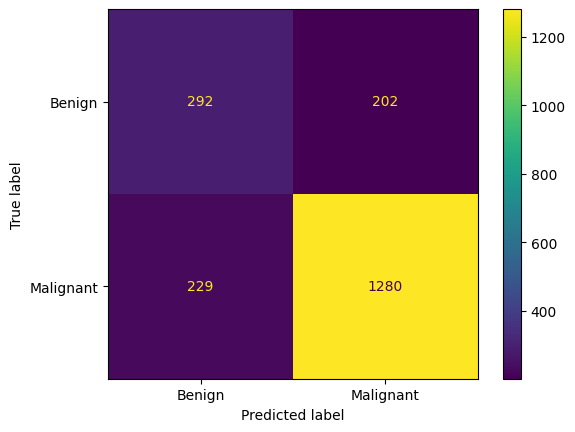

In [5]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train_res)

y_pred_rf = rf.predict(X_test_pca)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Benign (0)', 'Malignant (1)']))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot()
plt.show()